In [1]:
# Part 1: reusable helper functions
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Physical constants in cgs units
sigma_SB = 5.670374419e-5
G = 6.67430e-8
k_B = 1.380649e-16
m_H = 1.6735575e-24
M_sun = 1.98847e33
R_sun = 6.957e10
T_sun = 5778.0
AU = 1.495978707e13

def kappa_mean(T):
    """Planck/Rosseland mean opacity in cm^2 g^-1."""
    return (T / 2.0) ** 1.7

def sigma_g_profile(Sigma_g_1au, R_au):
    """Power-law gas surface density profile in g cm^-2."""
    return Sigma_g_1au * (R_au / 1.0) ** (-1.0)

def T_eq_surface(T_star, R_star, R_au):
    """Surface temperature from irradiation in K."""
    R_cm = R_au * AU
    return T_star * (R_star / (2.0 * R_cm)) ** (2.0 / 5.7)

def local_cooling_betas(
    a_s,
    Sigma_g_1au,
    R,
    rho_g_over_rho_d=100.0,
    T_star=T_sun,
    M_star=M_sun,
    R_star=R_sun,
    alpha_T=1.0,
    rho_int=1.0,
    gamma_g=1.4,
    mu=2.3,
    z_over_Hg=3.0,
):
    """Dimensionless cooling timescales for local disk surface model."""
    Sigma_g = sigma_g_profile(Sigma_g_1au, R)
    Omega = np.sqrt(G * M_star / (R * AU) ** 3)
    T_eq = T_eq_surface(T_star, R_star, R)
    kappa_P = kappa_mean(T_eq)
    c_d = 10.0 * T_eq**3
    c_p = (7.0 / 2.0) * k_B / (mu * m_H)

    St = (np.pi / 2.0) * (rho_int * a_s / Sigma_g) * np.exp(0.5 * z_over_Hg**2)

    common_rad = Omega / (16.0 * sigma_SB * kappa_P * T_eq**3)
    beta_rad_d = c_d * common_rad
    beta_rad_g = c_p * rho_g_over_rho_d * common_rad

    pref = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    beta_col_d = pref * (c_d / c_p) * St
    beta_col_g = pref * rho_g_over_rho_d * St

    return dict(
        Sigma_g=Sigma_g,
        T_eq=T_eq,
        St=St,
        beta_rad_d=beta_rad_d,
        beta_rad_g=beta_rad_g,
        beta_col_d=beta_col_d,
        beta_col_g=beta_col_g,
    )

def midplane_cooling_betas(
    a_s,
    Sigma_g_1au,
    R,
    alpha_grazing=0.075,
    T_star=T_sun,
    M_star=M_sun,
    R_star=R_sun,
    Sigma_g_over_Sigma_d=100.0,
    Hd_over_Hg=1.0,
    alpha_T=1.0,
    rho_int=1.0,
    gamma_g=1.4,
    mu=2.3,
):
    """Dimensionless cooling timescales for vertically integrated midplane model."""
    R_cm = R * AU
    Sigma_g = sigma_g_profile(Sigma_g_1au, R)
    T_eq = alpha_grazing ** 0.25 * (R_star / R_cm) ** 0.5 * T_star
    kappa = kappa_mean(T_eq)
    c_d = 10.0 * T_eq**3
    c_p = (7.0 / 2.0) * k_B / (mu * m_H)
    Omega = np.sqrt(G * M_star / R_cm**3)

    Sigma_d = Sigma_g / Sigma_g_over_Sigma_d
    tau_R = 0.5 * kappa * Sigma_d
    tau_P = 0.5 * kappa * Sigma_d
    tau_eff = (3.0 * tau_R / 8.0) + (np.sqrt(3.0) / 4.0) + (1.0 / (4.0 * tau_P))

    St_mid = (np.pi / 2.0) * (a_s * rho_int / Sigma_g)

    beta_rad_d = (Sigma_d * c_d * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)
    beta_rad_g = (Sigma_g * c_p * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)

    pref = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    geom = np.sqrt(1.0 + Hd_over_Hg**2)
    beta_col_d = pref * (c_d / c_p) * geom * St_mid
    beta_col_g = pref * Sigma_g_over_Sigma_d * geom * St_mid

    return dict(
        Sigma_g=Sigma_g,
        T_eq=T_eq,
        St=St_mid,
        beta_rad_d=beta_rad_d,
        beta_rad_g=beta_rad_g,
        beta_col_d=beta_col_d,
        beta_col_g=beta_col_g,
    )

def _cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

def convex_hull(points):
    """Monotonic chain convex hull for N x 2 points."""
    pts = np.array(sorted(points.tolist()))
    if len(pts) <= 2:
        return pts

    lower = []
    for p in pts:
        while len(lower) >= 2 and _cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and _cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))

    return np.array(lower[:-1] + upper[:-1])

def draw_possible_envelope(ax, xvals, yvals, fill_color="0.85", edge_color="0.45"):
    """Draw a simple boundary from a cloud in log(beta_col)-log(beta_rad) space."""
    pts = np.column_stack([np.log10(xvals), np.log10(yvals)])
    pts = np.unique(pts, axis=0)
    if len(pts) < 3:
        return
    hull = convex_hull(pts)
    hx = 10 ** hull[:, 0]
    hy = 10 ** hull[:, 1]
    ax.fill(
        hx, hy,
        facecolor=fill_color,
        edgecolor=edge_color,
        linewidth=1.2,
        alpha=0.35,
        zorder=0,
    )

def fmt_log(value):
    """Compact scientific formatter for legend values."""
    if value <= 0.0:
        return "0"
    exponent = int(np.floor(np.log10(value)))
    mantissa = value / (10 ** exponent)
    if np.isclose(mantissa, 1.0, rtol=0.03, atol=0.03):
        return rf"$10^{{{exponent}}}$"
    return rf"${mantissa:.1f}\times10^{{{exponent}}}$"

In [2]:
# Part 2: generate plotting data (fiducial + 1D sweeps + boundary search)
MODEL_FUNCS = {
    "local": local_cooling_betas,
    "midplane": midplane_cooling_betas,
}

N_TRACK = 4

FID_SURFACE = dict(a_s=1e-4, Sigma_g_1au=1.78e2, R=50.0)
FID_MIDPLANE = dict(a_s=1e-3, Sigma_g_1au=1.78e2, R=50.0)

# Model-specific boundary-search ranges.
SEARCH_RANGES_SURFACE = {
    "a_s": np.logspace(-5, -1, 16),
    "Sigma_g_1au": np.logspace(np.log10(1.780), np.log10(1780), 16),
    "R": np.logspace(0, np.log10(300.0), 16),
}

SEARCH_RANGES_MIDPLANE = {
    "a_s": np.logspace(-4, 0, 16),
    "Sigma_g_1au": np.logspace(np.log10(1.780), np.log10(1780), 16),
    "R": np.logspace(0, np.log10(300.0), 16),
}

ROW_CONFIGS = [
    dict(
        key="top",
        model="local",
        model_label="Local Disk Surface",
        legend_title=r"$a_s$ / St, $R$, and $\Sigma_g$",
        search_ranges=SEARCH_RANGES_SURFACE,
        track_specs=[
            dict(
                key="a_s",
                values=np.logspace(-5, -2, N_TRACK),
                fixed=dict(Sigma_g_1au=FID_SURFACE["Sigma_g_1au"], R=FID_SURFACE["R"]),
                cmap="YlOrRd",
                marker="o",
                label="$a_S$\nSt",
                show_st=True,
            ),
            dict(
                key="R",
                values=np.array([4, 16, 50, 200]),
                fixed=dict(a_s=FID_SURFACE["a_s"], Sigma_g_1au=FID_SURFACE["Sigma_g_1au"]),
                cmap="Greens",
                marker="^",
                label=r"$R$ [au]",
                show_st=False,
            ),
            dict(
                key="Sigma_g_1au",
                values=np.logspace(np.log10(1.780), np.log10(1780), N_TRACK),
                fixed=dict(a_s=FID_SURFACE["a_s"], R=FID_SURFACE["R"]),
                cmap="Blues",
                marker="s",
                label=r"$\Sigma_g$ [g cm$^{-2}$]",
                show_st=False,
            ),
        ],
    ),
    dict(
        key="bottom",
        model="midplane",
        model_label="Vertically Integrated Midplane",
        legend_title=r"$a_s$ / St, $\Sigma_g(R=50\,\mathrm{au})$ [g cm$^{-2}$]",
        search_ranges=SEARCH_RANGES_MIDPLANE,
        track_specs=[
            dict(
                key="a_s",
                values=np.logspace(-3, 0, N_TRACK),
                fixed=dict(Sigma_g_1au=FID_MIDPLANE["Sigma_g_1au"], R=FID_MIDPLANE["R"]),
                cmap="YlOrRd",
                marker="o",
                label="$a_S$\nSt",
                show_st=True,
            ),
            dict(
                key="R",
                values=np.array([4, 16, 50, 200]),
                fixed=dict(a_s=FID_MIDPLANE["a_s"], Sigma_g_1au=FID_MIDPLANE["Sigma_g_1au"]),
                cmap="Greens",
                marker="^",
                label=r"$R$ [au]",
                show_st=False,
            ),
            dict(
                key="Sigma_g_1au",
                values=np.logspace(np.log10(1.780), np.log10(1780), N_TRACK),
                fixed=dict(a_s=FID_MIDPLANE["a_s"], R=FID_MIDPLANE["R"]),
                cmap="Blues",
                marker="s",
                label=r"$\Sigma_g(R=50\,\mathrm{au})$" + " [g cm$^{-2}$]",
                show_st=False,
            ),
        ],
    ),
]

def evaluate_model(model_name, params):
    return MODEL_FUNCS[model_name](**params)

def build_boundary_cloud(model_name, ranges):
    bc_d, br_d, bc_g, br_g = [], [], [], []
    for a_s in ranges["a_s"]:
        for sigma1 in ranges["Sigma_g_1au"]:
            for radius in ranges["R"]:
                out = evaluate_model(model_name, dict(a_s=a_s, Sigma_g_1au=sigma1, R=radius))
                bc_d.append(out["beta_col_d"]); br_d.append(out["beta_rad_d"])
                bc_g.append(out["beta_col_g"]); br_g.append(out["beta_rad_g"])
    return dict(
        beta_col_d=np.asarray(bc_d),
        beta_rad_d=np.asarray(br_d),
        beta_col_g=np.asarray(bc_g),
        beta_rad_g=np.asarray(br_g),
    )

def sample_track_values(search_values, n_points):
    idx = np.linspace(0, len(search_values) - 1, n_points).astype(int)
    return np.asarray(search_values)[idx]

def build_track(model_name, spec):
    values = np.asarray(spec["values"])
    n = len(values)
    bc_d = np.empty(n)
    br_d = np.empty(n)
    bc_g = np.empty(n)
    br_g = np.empty(n)
    st_vals = np.empty(n)
    sigma_local_vals = np.empty(n)

    for i, value in enumerate(values):
        params = dict(spec["fixed"])
        params[spec["key"]] = value
        out = evaluate_model(model_name, params)
        bc_d[i] = out["beta_col_d"]
        br_d[i] = out["beta_rad_d"]
        bc_g[i] = out["beta_col_g"]
        br_g[i] = out["beta_rad_g"]
        st_vals[i] = out["St"]
        sigma_local_vals[i] = out["Sigma_g"]

    base_cmap = plt.colormaps[spec["cmap"]]
    colors = [base_cmap(0.25 + 0.75 * i / max(1, n - 1)) for i in range(n)]

    display_values = values
    if spec["key"] == "Sigma_g_1au":
        display_values = sigma_local_vals

    return dict(
        key=spec["key"],
        label=spec["label"],
        marker=spec["marker"],
        show_st=spec["show_st"],
        sweep_values=values,
        display_values=display_values,
        st_values=st_vals,
        colors=colors,
        beta_col_d=bc_d,
        beta_rad_d=br_d,
        beta_col_g=bc_g,
        beta_rad_g=br_g,
    )

def padded_lims(values, pad=0.2):
    lo = np.min(values)
    hi = np.max(values)
    return 10 ** (np.log10(lo) - pad), 10 ** (np.log10(hi) + pad)

def collect_row_data(row_cfg):
    cloud = build_boundary_cloud(row_cfg["model"], row_cfg["search_ranges"])
    tracks = [build_track(row_cfg["model"], spec) for spec in row_cfg["track_specs"]]

    all_x_d = list(cloud["beta_col_d"]); all_y_d = list(cloud["beta_rad_d"])
    all_x_g = list(cloud["beta_col_g"]); all_y_g = list(cloud["beta_rad_g"])

    for track in tracks:
        all_x_d.extend(track["beta_col_d"]); all_y_d.extend(track["beta_rad_d"])
        all_x_g.extend(track["beta_col_g"]); all_y_g.extend(track["beta_rad_g"])

    limits = dict(
        dust_x=padded_lims(np.asarray(all_x_d)),
        dust_y=padded_lims(np.asarray(all_y_d)),
        gas_x=padded_lims(np.asarray(all_x_g)),
        gas_y=padded_lims(np.asarray(all_y_g)),
    )
    return dict(config=row_cfg, cloud=cloud, tracks=tracks, limits=limits)

plot_rows = [collect_row_data(cfg) for cfg in ROW_CONFIGS]

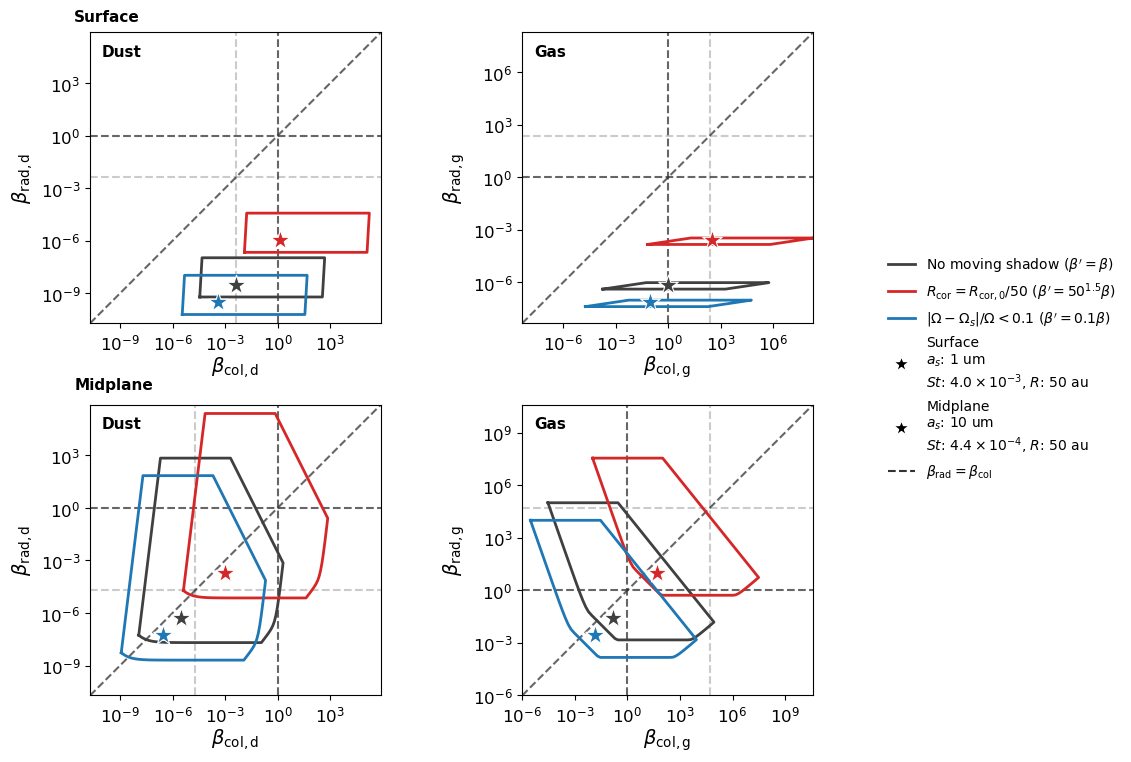

In [15]:
# Part 3: moving-shadows visualization (boundaries + fiducials only)

from matplotlib import ticker as mticker
from matplotlib.lines import Line2D

FS_AXIS_TITLE = 14
FS_AXIS_LABEL = 14
FS_TICK = 12
FS_LEGEND_LABEL = 11
XLABEL_PAD = 1

FID_STAR_SIZE_PANEL = 220

# Shadow scenarios represented via beta' = scale * beta.
SCENARIOS = [
    dict(
        key="baseline",
        label=r"No moving shadow ($\beta'=\beta$)",
        scale=1.0,
        color="0.25",
        ls="-",
        lw=2.0,
    ),
    dict(
        key="fast_shadow",
        label=r"$R_{\rm cor}=R_{\rm cor,0}/50$ ($\beta'=50^{1.5}\beta$)",
        scale=50.0 ** 1.5,
        color="#d62728",
        ls="-",
        lw=2.0,
    ),
    dict(
        key="finite_width",
        label=r"$|\Omega-\Omega_s|/\Omega<0.1$ ($\beta'=0.1\beta$)",
        scale=0.1,
        color="#1f77b4",
        ls="-",
        lw=2.0,
    ),
]


def style_phase_axis(ax, xlim, ylim, side):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$\beta_{\rm col," + side + r"}$", fontsize=FS_AXIS_LABEL, labelpad=XLABEL_PAD)
    ax.set_ylabel(r"$\beta_{\rm rad," + side + r"}$", fontsize=FS_AXIS_LABEL)
    ax.tick_params(axis="both", which="both", labelsize=FS_TICK)
    ax.grid(False)


def set_power_ticks_with_unity(ax, axis="x", step=3):
    lim = ax.get_xlim() if axis == "x" else ax.get_ylim()
    lo, hi = min(lim), max(lim)
    if not (np.isfinite(lo) and np.isfinite(hi)) or lo <= 0.0 or hi <= lo:
        return

    n_min = int(np.floor(np.log10(lo)))
    n_max = int(np.ceil(np.log10(hi)))
    exponents = np.arange(n_min, n_max + 1)
    major_exponents = exponents[exponents % step == 0]

    if lo <= 1.0 <= hi and 0 not in major_exponents:
        major_exponents = np.append(major_exponents, 0)

    major_exponents = np.unique(major_exponents)
    ticks = 10.0 ** major_exponents

    if axis == "x":
        ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
        ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))
        ax.xaxis.set_minor_locator(mticker.NullLocator())
    else:
        ax.yaxis.set_major_locator(mticker.FixedLocator(ticks))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))
        ax.yaxis.set_minor_locator(mticker.NullLocator())


def apply_sparse_ticks(ax):
    set_power_ticks_with_unity(ax, axis="x", step=3)
    set_power_ticks_with_unity(ax, axis="y", step=3)


def plot_y_eq_x_with_final_limits(ax, **line_kwargs):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = max(xlim[0], ylim[0])
    hi = min(xlim[1], ylim[1])
    if not (np.isfinite(lo) and np.isfinite(hi)) or lo <= 0.0 or hi <= lo:
        return
    x_ref = np.logspace(np.log10(lo), np.log10(hi), 256)
    ax.plot(x_ref, x_ref, **line_kwargs)


def draw_primary_guides(ax):
    ax.axvline(1.0, ls="--", lw=1.5, color="0.20", zorder=0, alpha=0.75)
    ax.axhline(1.0, ls="--", lw=1.5, color="0.20", zorder=0, alpha=0.75)
    plot_y_eq_x_with_final_limits(ax, ls="--", lw=1.5, color="0.20", zorder=0, alpha=0.75)


def draw_secondary_cross_guides(ax, value):
    if not np.isfinite(value) or value <= 0.0:
        return
    ax.axvline(value, ls="--", lw=1.5, color="0.2", zorder=0, alpha=0.25)
    ax.axhline(value, ls="--", lw=1.5, color="0.2", zorder=0, alpha=0.25)


def draw_scaled_boundary(ax, xvals, yvals, scale, color, ls="-", lw=2.0):
    pts = np.column_stack([np.log10(xvals * scale), np.log10(yvals * scale)])
    pts = np.unique(pts, axis=0)
    if len(pts) < 3:
        return
    hull = convex_hull(pts)
    hx = 10 ** hull[:, 0]
    hy = 10 ** hull[:, 1]
    hx = np.append(hx, hx[0])
    hy = np.append(hy, hy[0])
    ax.plot(hx, hy, color=color, ls=ls, lw=lw, zorder=1)


def fiducial_point(row_data, side):
    if row_data["config"]["model"] == "local":
        out = local_cooling_betas(**FID_SURFACE)
    else:
        out = midplane_cooling_betas(**FID_MIDPLANE)

    if side == "d":
        return out["beta_col_d"], out["beta_rad_d"]
    return out["beta_col_g"], out["beta_rad_g"]


def plot_panel(ax, row_data, side):
    if side == "d":
        cloud_x = row_data["cloud"]["beta_col_d"]
        cloud_y = row_data["cloud"]["beta_rad_d"]
        xlim = row_data["limits"]["dust_x"]
        ylim = row_data["limits"]["dust_y"]
    else:
        cloud_x = row_data["cloud"]["beta_col_g"]
        cloud_y = row_data["cloud"]["beta_rad_g"]
        xlim = row_data["limits"]["gas_x"]
        ylim = row_data["limits"]["gas_y"]

    # Expand limits so shifted scenarios are visible.
    scale_max = max(s["scale"] for s in SCENARIOS)
    scale_min = min(s["scale"] for s in SCENARIOS)
    xlim = (xlim[0] * scale_min / 2.0, xlim[1] * scale_max * 2.0)
    ylim = (ylim[0] * scale_min / 2.0, ylim[1] * scale_max * 2.0)

    style_phase_axis(ax, xlim, ylim, side)

    for scenario in SCENARIOS:
        draw_scaled_boundary(
            ax,
            cloud_x,
            cloud_y,
            scale=scenario["scale"],
            color=scenario["color"],
            ls=scenario["ls"],
            lw=scenario["lw"],
        )

        fx, fy = fiducial_point(row_data, side)
        ax.scatter(
            fx * scenario["scale"],
            fy * scenario["scale"],
            s=FID_STAR_SIZE_PANEL,
            marker="*",
            color=scenario["color"],
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
        )

    apply_sparse_ticks(ax)


def fiducial_gas_to_dust_ratio(row_data):
    if row_data["config"]["model"] == "local":
        ref = local_cooling_betas(**FID_SURFACE)
    else:
        ref = midplane_cooling_betas(**FID_MIDPLANE)
    return ref["beta_rad_g"] / ref["beta_rad_d"]


def fmt_summary_value(value):
    if value <= 0.0:
        return "0"
    exponent = int(np.floor(np.log10(value)))
    mantissa = value / (10 ** exponent)
    if np.isclose(mantissa, 1.0, rtol=0.03, atol=0.03):
        return rf"10^{{{exponent}}}"
    return rf"{mantissa:.1f}\times10^{{{exponent}}}"


def fiducial_summary_label(row_data):
    if row_data["config"]["model"] == "local":
        ref = local_cooling_betas(**FID_SURFACE)
        row_label = "Surface"
        size_text = f'{FID_SURFACE["a_s"] * 1e4:g} um'
        r_text = f'{FID_SURFACE["R"]:g} au'
    else:
        ref = midplane_cooling_betas(**FID_MIDPLANE)
        row_label = "Midplane"
        size_text = f'{FID_MIDPLANE["a_s"] * 1e4:g} um'
        r_text = f'{FID_MIDPLANE["R"]:g} au'
    st_text = fmt_summary_value(ref["St"])
    return f"{row_label}\n$a_s$: {size_text}\n$St$: ${st_text}$, $R$: {r_text}"


fig = plt.figure(figsize=(11.0, 7.8))
gs = fig.add_gridspec(
    2,
    2,
    hspace=0.28,
    wspace=0.10,
    left=0.08,
    right=0.83,
    top=0.93,
    bottom=0.08,
)

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])

plot_panel(ax00, plot_rows[0], "d")
plot_panel(ax01, plot_rows[0], "g")
plot_panel(ax10, plot_rows[1], "d")
plot_panel(ax11, plot_rows[1], "g")

for ax in [ax00, ax01, ax10, ax11]:
    ax.set_aspect("equal", adjustable="box")

# Enforce a single shared dust-domain for both left panels and x/y equality in each panel.
ratio_top = max(fiducial_gas_to_dust_ratio(plot_rows[0]), 1e-30)
ratio_bottom = max(fiducial_gas_to_dust_ratio(plot_rows[1]), 1e-30)

x00 = ax00.get_xlim(); y00 = ax00.get_ylim()
x10 = ax10.get_xlim(); y10 = ax10.get_ylim()
left_lo = min(x00[0], y00[0], x10[0], y10[0])
left_hi = max(x00[1], y00[1], x10[1], y10[1])
left_lim = (left_lo, left_hi)

ax00.set_xlim(*left_lim)
ax00.set_ylim(*left_lim)
ax10.set_xlim(*left_lim)
ax10.set_ylim(*left_lim)

top_right_lim = (left_lim[0] * ratio_top, left_lim[1] * ratio_top)
bottom_right_lim = (left_lim[0] * ratio_bottom, left_lim[1] * ratio_bottom)
ax01.set_xlim(*top_right_lim)
ax01.set_ylim(*top_right_lim)
ax11.set_xlim(*bottom_right_lim)
ax11.set_ylim(*bottom_right_lim)

# Main guides in each panel.
for ax in [ax00, ax01, ax10, ax11]:
    draw_primary_guides(ax)

# Cross-panel mapped guides (left <-> right) for each row.
draw_secondary_cross_guides(ax00, 1.0 / ratio_top)
draw_secondary_cross_guides(ax01, ratio_top)
draw_secondary_cross_guides(ax10, 1.0 / ratio_bottom)
draw_secondary_cross_guides(ax11, ratio_bottom)

for ax in [ax00, ax01, ax10, ax11]:
    apply_sparse_ticks(ax)

fig.text(0.112, 0.950, "Surface", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="center")
fig.text(0.112, 0.478, "Midplane", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="center")
ax00.text(0.04, 0.96, "Dust", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="top", transform=ax00.transAxes)
ax01.text(0.04, 0.96, "Gas", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="top", transform=ax01.transAxes)
ax10.text(0.04, 0.96, "Dust", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="top", transform=ax10.transAxes)
ax11.text(0.04, 0.96, "Gas", fontsize=FS_LEGEND_LABEL, fontweight="bold", ha="left", va="top", transform=ax11.transAxes)

legend_handles = [
    Line2D([], [], color=s["color"], lw=s["lw"], ls=s["ls"], label=s["label"]) for s in SCENARIOS
]
legend_handles += [
    Line2D([], [], color="k", marker="*", lw=0, markersize=FID_STAR_SIZE_LEGEND, markeredgecolor="white", label=fiducial_summary_label(plot_rows[0])),
    Line2D([], [], color="k", marker="*", lw=0, markersize=FID_STAR_SIZE_LEGEND, markeredgecolor="white", label=fiducial_summary_label(plot_rows[1])),
    Line2D([], [], color="0.20", ls="--", lw=1.5, label=r"$\beta_{\rm rad}=\beta_{\rm col}$"),
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.84, 0.50),
    frameon=False,
    fontsize=10,
)

plt.savefig("cooling_phase_space_moving_shadows.pdf", transparent=True, dpi=300, bbox_inches="tight")
plt.show()


6973.315208708122

[]

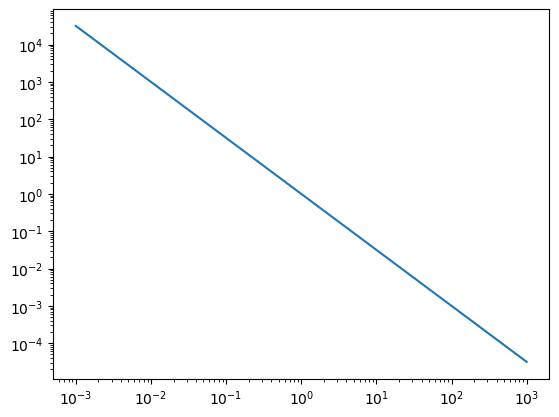

In [6]:
plt.plot(np.logspace(-3,3,100), np.logspace(-3,3,100)**-1.5)
plt.axhline(.0, ls="--", color="k")
plt.loglog()

In [59]:
# Diagnostic: current vs old-like sweep maxima for midplane beta_col,d
def max_beta_col_mid(a_vals, s_vals, r_vals):
    m = -np.inf
    arg = None
    for a in a_vals:
        for s in s_vals:
            for r in r_vals:
                v = midplane_cooling_betas(a_s=a, Sigma_g_1au=s, R=r)["beta_col_d"]
                if v > m:
                    m = v
                    arg = (a, s, r)
    return m, arg

current_max, current_arg = max_beta_col_mid(
    np.logspace(-5, -1, 16),
    np.logspace(2, 5, 16),
    np.logspace(0, np.log10(300.0), 16),
)

oldlike_max, oldlike_arg = max_beta_col_mid(
    np.logspace(-4, 0, 10),
    np.logspace(1, 4, 10),
    np.logspace(0, np.log10(300.0), 10),
)

print("current-grid max beta_col,d:", f"{current_max:.3e}", "at", current_arg)
print("old-like-grid max beta_col,d:", f"{oldlike_max:.3e}", "at", oldlike_arg)

current-grid max beta_col,d: 3.620e-03 at (np.float64(0.1), np.float64(100.0), np.float64(1.0))
old-like-grid max beta_col,d: 3.620e-01 at (np.float64(1.0), np.float64(10.0), np.float64(1.0))
